# 01 Scalar Case Diagnostics

I start with the shortlist because it is the quickest way to see whether the scalar twin is producing physically plausible beams for the writing targets. The summary now shows both the legacy peak-trace Bessel zone and the stricter stable Bessel region, so I can immediately see when the old z metric was being generous.

## Stage 8.7 Adjustable Quick-Look Guidance

<!-- STAGE87: adjustable quicklook guidance -->

For fast parameter scouting, use `notebooks/quicklook/00_quick_beam_to_sample_simulator.ipynb`. This notebook remains on its locked stage path: existing execution logic, propagation-power labels, material-proxy caveats, and governance routing are unchanged.

Safe local edits are the explicit config variables already exposed by this notebook, or a copied exploratory run. Keep `fail` and `marginal` labels visible. If a displayed image is visually smoothed, treat that as display interpolation only; rerun balanced/publication sampling before numerical interpretation.


In [ ]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from vbb_study import setup_study, vbb_style

PATHS = setup_study.bootstrap(Path.cwd())
ROOT = PATHS["root"]
PUB_ROOT = PATHS["publication"]
LAB_ROOT = PATHS["modular_lab"]

import bessel_twin_core as bt
from Publication_Study import publication_diagnostics as pdiag

## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [ ]:
# STAGE88: visible editable controls for exploratory notebook use.
# Edit NOTEBOOK_CONTROLS below and re-run this cell to apply parameter
# overrides to `base` before running any study cell below.
from dataclasses import replace
from vbb_study.publication import notebook_controls as nb_controls
from vbb_study.config import um as _um

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(
    stage='scalar',
    # ── edit these to override the base configuration ───────────────────────
    ell=3,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    objective_NA=0.45,
    blaze_period_px=20,
)

# Build a base config and wire control parameters into it.
base = bt.default_config("fast")
_p = NOTEBOOK_CONTROLS.parameters or {}
if "ell" in _p:
    base = replace(base, target=replace(base.target, ell=int(_p["ell"])))
if "target_core_diameter_um" in _p:
    base = replace(base, target=replace(base.target, target_core_diameter_m=float(_p["target_core_diameter_um"]) * _um))
if "target_bessel_length_um" in _p:
    base = replace(base, target=replace(base.target, target_bessel_length_m=float(_p["target_bessel_length_um"]) * _um))
if "objective_NA" in _p:
    base = replace(base, objective=replace(base.objective, NA=float(_p["objective_NA"])))
if "blaze_period_px" in _p:
    base = replace(base, slm=replace(base.slm, blaze_period_px=int(_p["blaze_period_px"])))

try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


In [ ]:
# Interactive quicklook — adjust sliders and click "Update plots".
# Runs a fast preview only; nothing is saved.
from vbb_study.publication import notebook_widgets as nbw

_panel = nbw.interactive_quicklook(base, method='holographic', preset='fast')
display(_panel)


In [ ]:
# PHASE7: canonical schema import
# Imports the canonical scalar output schema helpers.
# source_schema_version is embedded in every row written to CSV.
from vbb_study.publication.tables import (
    SCALAR_OUTPUT_SCHEMA_VERSION,
    SCALAR_SUMMARY_COLUMNS,
    annotate_scalar_row,
    ordered_row,
    propagation_power_label as _power_label,
)
print(f"Scalar output schema version: {SCALAR_OUTPUT_SCHEMA_VERSION}")
print(f"Canonical columns: {len(SCALAR_SUMMARY_COLUMNS)} defined in tables.py")


Scalar output schema version: 2.0.0
Canonical columns: 30 defined in tables.py


In [ ]:
# PHASE7: fast-preset caution
# This notebook was last executed with the 'fast' grid preset.
# The fast preset is a DIAGNOSTIC / DEBUG speed mode:
#   - small grid (N=512), coarse axial sampling
#   - may show propagation_power_label='fail' (>20% power drift)
#   - NOT suitable as the primary source for publication figures
#
# Publication preset improves propagation-power drift, but does NOT certify
# every case as publication-ready. Preserve propagation_power_label and inspect
# fail rows as numerical diagnostics or rerun with finer grid/sampling/model setup.
# See: tools/regen_scalar_shortlist.py --preset publication
#
# Cases with propagation_power_label='fail' MUST NOT be reported as
# publication-ready or hidden by threshold relaxation.
import os as _os
_rid = _os.environ.get("STRUCTURED_BEAM_RUN_ID", "interactive")
_preset_env = _os.environ.get("STRUCTURED_BEAM_PRESET", "fast")
print(f"[Phase7 caution] run_id={_rid!r}  preset={_preset_env!r}")
print("[Phase7 caution] Fast preset: results are diagnostic quality only.")
print("[Phase7 caution] Publication preset improves drift but may still leave fail cases.")


[Phase7 caution] run_id='20260603T200130Z'  preset='fast'
[Phase7 caution] Fast preset: results are diagnostic quality only.
[Phase7 caution] Publication preset improves drift but may still leave fail cases.


In [ ]:
PRESET = "fast"
PATH = "realistic"
OUTPUTS = bt.ensure_output_tree(PATHS["outputs"])
PUB_FIG_DIR = OUTPUTS["figures"] / "publication_study"
PUB_CSV_DIR = OUTPUTS["csv"] / "publication_study"
PUB_FIG_DIR.mkdir(parents=True, exist_ok=True)
PUB_CSV_DIR.mkdir(parents=True, exist_ok=True)
base = bt.default_config(PRESET)

## Shortlist Comparison

Reuse the experiment-planning shortlist, but run the realistic device-to-sample path so the publication figures reflect the lab-facing model rather than the ideal analytic path.

In [ ]:
import os as _os
from vbb_study.studies import scalar_cases

summary = scalar_cases.run_shortlist(
    preset=PRESET,
    path=PATH,
    run_id=_os.environ.get("STRUCTURED_BEAM_RUN_ID"),
    qa_status="exploratory",
)
scalar_cases.save_shortlist_csv(
    summary,
    PUB_CSV_DIR,
    filename="scalar_shortlist_realistic_summary.csv",
)

detail_shortlist = pdiag.DEFAULT_SHORTLIST
bundles = pdiag.build_shortlist_bundles(detail_shortlist, base, preset=PRESET, path=PATH)
display(summary)

,run_id,generated_at_utc,source_schema_version,preset,path,case_id,target_scale_definition,target_core_diameter_um,target_equivalent_l0_core_diameter_um,equivalent_l0_first_zero_radius_um,...,propagation_power_clipping_note,sas_retained_power_fraction_mean,validity_valid,validity_violations,validity_samples_per_feature,validity_samples_per_radial_period,validity_samples_per_axial_zone,validity_output_dx_um,validity_action,regime
0,20260603T200130Z,2026-06-03T20:01:48.616231+00:00,2.0.0,fast,realistic,ell0_core3_L150,equivalent_l0_first_zero_diameter,3.0,3.0,1.5,...,"Total propagated-power drift; pass<=0.05, marg...",1.0,True,,11.941691,15.599139,16.000000,0.251221,pass,general
1,20260603T200130Z,2026-06-03T20:01:50.635826+00:00,2.0.0,fast,realistic,ell1_core3_L150,equivalent_l0_first_zero_diameter,3.0,3.0,1.5,...,"Total propagated-power drift; pass<=0.05, marg...",1.0,True,,11.941691,15.599139,16.000000,0.251221,pass,general
2,20260603T200130Z,2026-06-03T20:01:52.827381+00:00,2.0.0,fast,realistic,ell2_core3_L150,equivalent_l0_first_zero_diameter,3.0,3.0,1.5,...,"Total propagated-power drift; pass<=0.05, marg...",1.0,True,,11.941691,15.599139,16.000000,0.251221,pass,general
3,20260603T200130Z,2026-06-03T20:01:55.023068+00:00,2.0.0,fast,realistic,ell3_core3_L150,equivalent_l0_first_zero_diameter,3.0,3.0,1.5,...,"Total propagated-power drift; pass<=0.05, marg...",1.0,True,,11.941691,15.599139,16.000000,0.251221,pass,general
4,20260603T200130Z,2026-06-03T20:01:56.898836+00:00,2.0.0,fast,realistic,ell0_core5_L300,equivalent_l0_first_zero_diameter,5.0,5.0,2.5,...,"Total propagated-power drift; pass<=0.05, marg...",1.0,True,,19.902818,25.998565,16.000000,0.251221,pass,general
5,20260603T200130Z,2026-06-03T20:01:58.670997+00:00,2.0.0,fast,realistic,ell1_core5_L300,equivalent_l0_first_zero_diameter,5.0,5.0,2.5,...,"Total propagated-power drift; pass<=0.05, marg...",1.0,True,,19.902818,25.998565,16.000000,0.251221,pass,general
6,20260603T200130Z,2026-06-03T20:02:00.523729+00:00,2.0.0,fast,realistic,ell0_core2_L100,equivalent_l0_first_zero_diameter,2.0,2.0,1.0,...,"Total propagated-power drift; pass<=0.05, marg...",1.0,True,,7.961127,10.399426,7.511483,0.251221,pass,general


## Detailed Case Review

Pick one shortlist case for a deeper publication diagnostic panel, energy-budget review, and axial plane montage.

In [ ]:
CASE_LABEL = "ell3_core3_L150"
selected = next(bundle for bundle in bundles if bundle["case_id"] == CASE_LABEL)
display(selected["summary"])
display(selected["energy_budget"])

,metric,value
0,case_id,ell3_core3_L150
1,path,realistic
2,ell,3
3,target_core_diameter_um,3.0
4,target_scale_definition,equivalent_l0_first_zero_diameter
...,...,...
62,axial_sampling_label,pass
63,focal_kt_nyquist_over_kr,7.799569
64,focal_samples_per_radial_period,15.599139
65,axial_dz_um,6.75


,stage_order,stage,incremental_transmission,cumulative_transmission,pulse_energy_uJ
0,0,Input pulse,1.00,1.000000,10.00000
1,1,Pre-SLM optics,1.00,1.000000,10.00000
2,2,SLM reflectivity,0.75,0.750000,7.50000
3,3,First-order efficiency,0.45,0.337500,3.37500
4,4,Relay transmission,0.90,0.303750,3.03750
5,5,Focusing transmission,0.90,0.273375,2.73375
6,6,User transmission,1.00,0.273375,2.73375


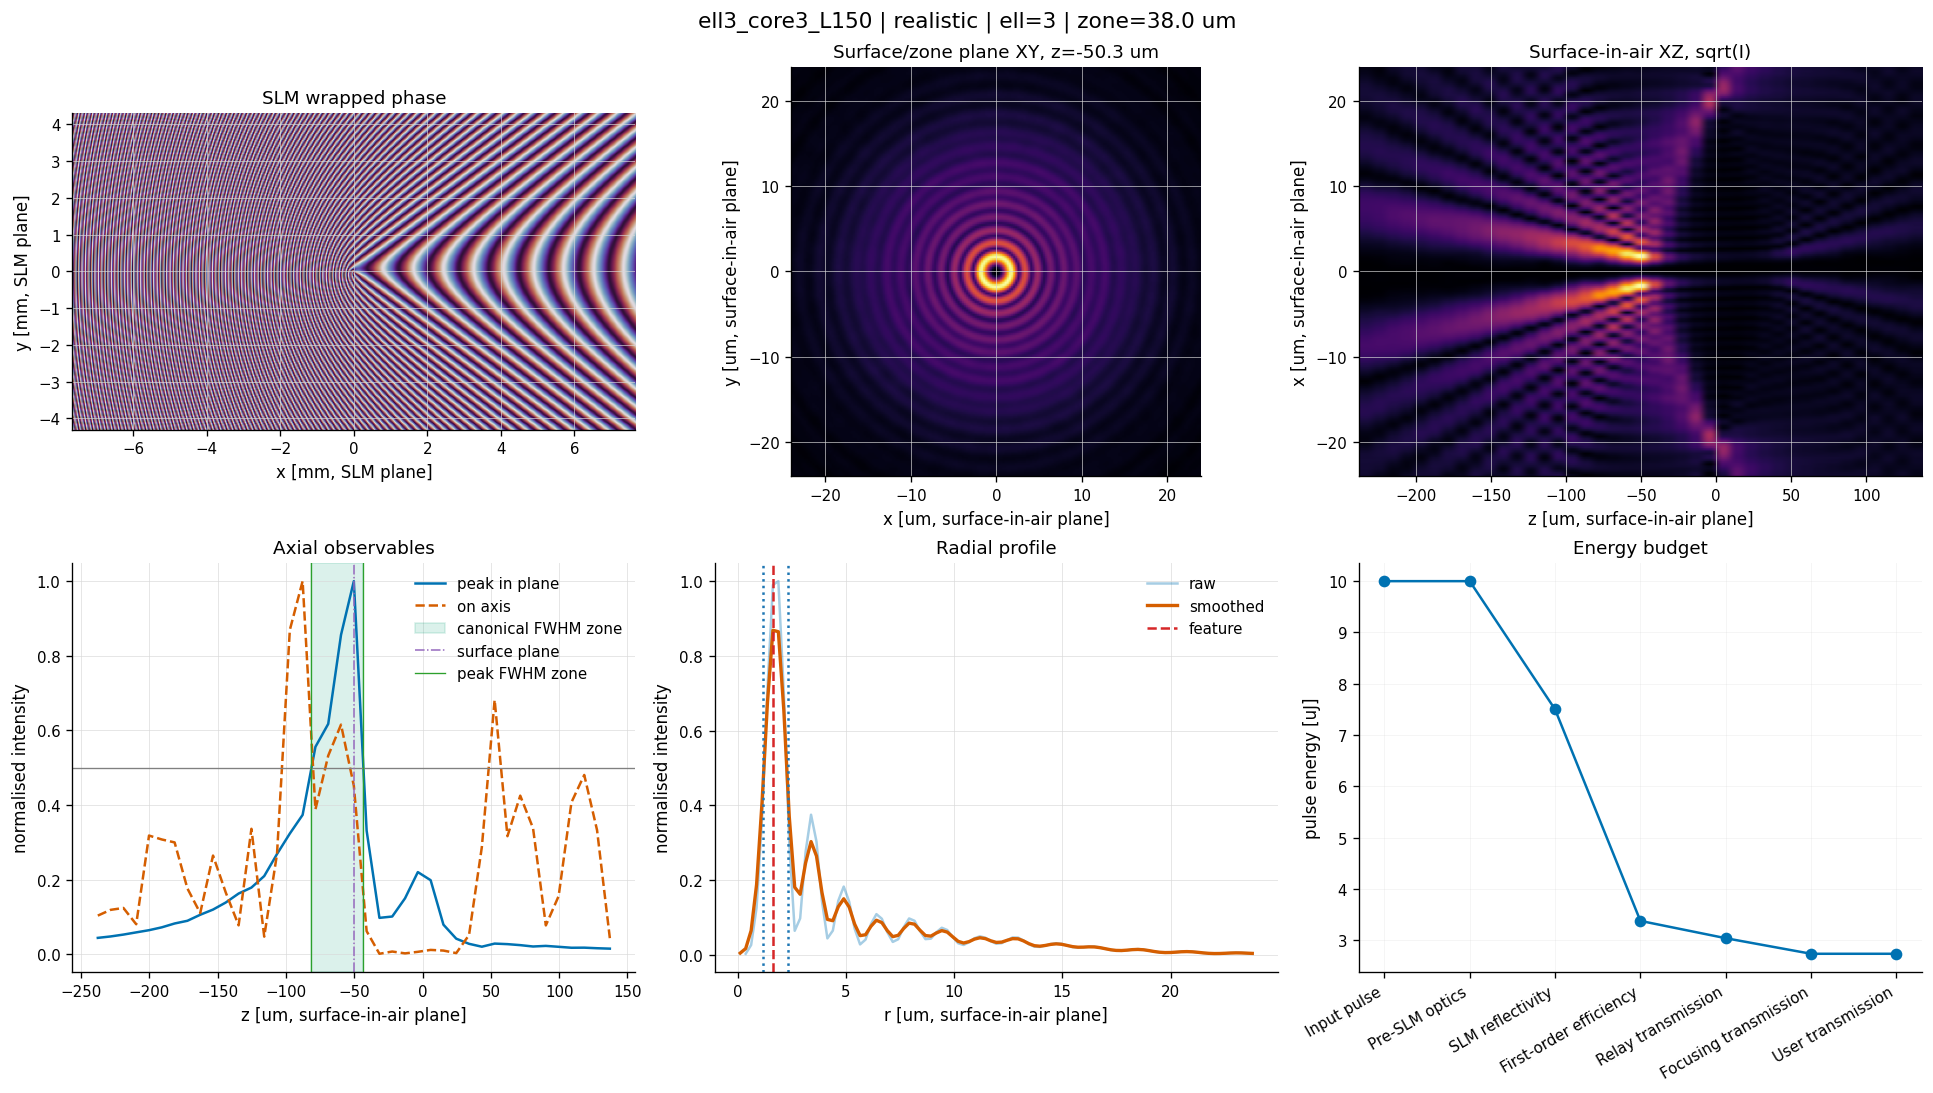

In [ ]:
fig = pdiag.plot_case_diagnostics(selected)
plt.show()

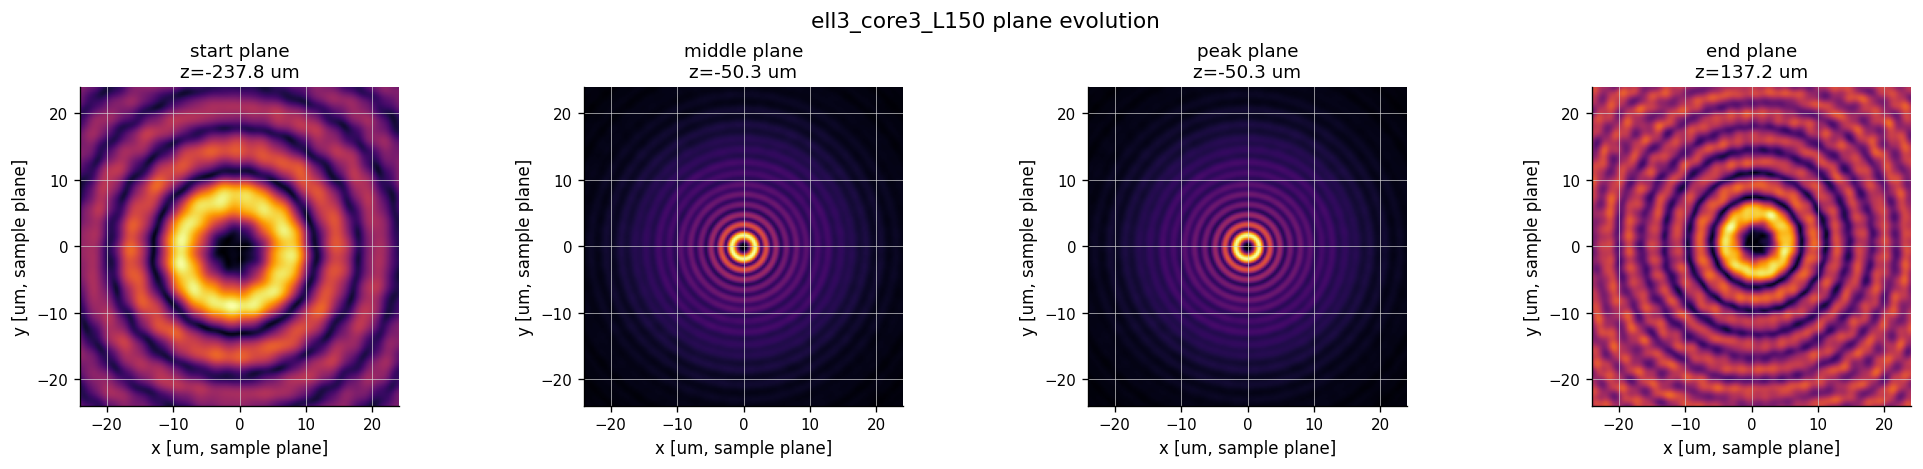

In [ ]:
fig = pdiag.plot_axial_plane_montage(selected)
plt.show()

## Shortlist Metric Comparison

Quick bar plots for the shortlist so the case selection logic is visible in the same notebook as the figures.

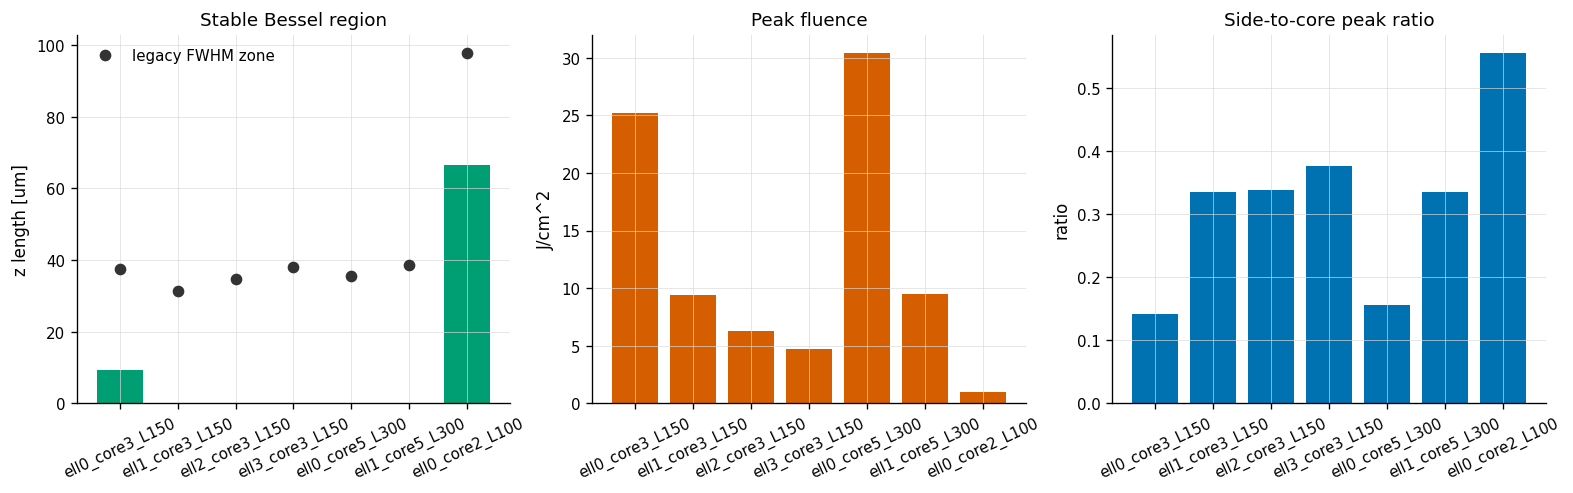

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
region_col = "bessel_region_um" if "bessel_region_um" in summary else "bessel_zone_um"
ax[0].bar(summary["case_id"], summary[region_col], color=vbb_style.CATEGORICAL_PALETTE[2])
ax[0].plot(summary["case_id"], summary["bessel_zone_um"], "o", color="0.2", label="legacy FWHM zone")
ax[0].set_title("Stable Bessel region")
ax[0].set_ylabel("z length [um]")
ax[0].tick_params(axis="x", rotation=25)
ax[0].legend(frameon=False)
ax[1].bar(summary["case_id"], summary["peak_fluence_J_cm2"], color=vbb_style.CATEGORICAL_PALETTE[1])
ax[1].set_title("Peak fluence")
ax[1].set_ylabel("J/cm^2")
ax[1].tick_params(axis="x", rotation=25)
ax[2].bar(summary["case_id"], summary["side_to_core_peak_ratio"], color=vbb_style.CATEGORICAL_PALETTE[0])
ax[2].set_title("Side-to-core peak ratio")
ax[2].set_ylabel("ratio")
ax[2].tick_params(axis="x", rotation=25)
plt.show()

## Export Figures

Save the selected-case figures into the publication-study output subtree so they are reproducible and easy to collect for manuscript drafting.

In [ ]:
diag_path = PUB_FIG_DIR / f"{CASE_LABEL}_diagnostics.png"
montage_path = PUB_FIG_DIR / f"{CASE_LABEL}_plane_montage.png"
fig1 = pdiag.plot_case_diagnostics(selected)
fig1.savefig(diag_path, dpi=220, bbox_inches="tight")
plt.close(fig1)
fig2 = pdiag.plot_axial_plane_montage(selected)
fig2.savefig(montage_path, dpi=220, bbox_inches="tight")
plt.close(fig2)
print(diag_path)
print(montage_path)

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\ell3_core3_L150_diagnostics.png
C:\PhD\Code\Publication_Study\outputs\figures\publication_study\ell3_core3_L150_plane_montage.png


In [ ]:
# PHASE7: propagation power QA
# Check propagation power drift for all cases found in notebook global scope.
# pass <= 5%, marginal <= 20%, fail > 20%.
# Fast preset is diagnostic/debug only. Publication preset improves drift, but
# does not make every case publication-ready; fail rows stay visible and should
# be treated as numerical diagnostics or rerun with finer grid/sampling/model setup.
import pandas as pd  # noqa: F811 (safe re-import)
_found_qa = False
for _name in [
    "summary",
    "df",
    "shortlist_df",
    "summary_df",
    "comparison_table",
    "preset_comparison",
    "oat",
    "tradeoff",
    "ell_family",
    "device_realism",
    "interface_depth",
]:
    _df = globals().get(_name)
    if _df is not None and isinstance(_df, pd.DataFrame) and "propagation_power_label" in _df.columns:
        _qa_cols = ["preset", "case_id", "propagation_power_drift_fraction", "propagation_power_label"]
        _qa = _df[[c for c in _qa_cols if c in _df.columns]].copy()
        if "preset" not in _qa.columns:
            _qa["preset"] = globals().get("PRESET", "unknown")
        _summary = (
            _qa.groupby("preset", dropna=False)["propagation_power_label"]
            .value_counts()
            .unstack(fill_value=0)
            .reindex(columns=["pass", "marginal", "fail"], fill_value=0)
            .reset_index()
        )
        print(f"Power QA counts by preset for '{_name}':")
        print(_summary.to_string(index=False))
        _pass = int((_qa["propagation_power_label"] == "pass").sum())
        _marginal = int((_qa["propagation_power_label"] == "marginal").sum())
        _fail = int((_qa["propagation_power_label"] == "fail").sum())
        print(f"Power QA for '{_name}': {_pass} pass, {_marginal} marginal, {_fail} fail")
        if _fail > 0:
            print("WARNING: FAIL cases (>20% drift) are NOT suitable for publication figures.")
        if _marginal > 0:
            print("NOTE: MARGINAL cases (5-20% drift) — review before publication.")
        _found_qa = True
        break
if not _found_qa:
    print("NOTE: power QA cell ran — no scalar summary DataFrame found in scope yet.")
    print("      Re-run this cell AFTER the cell that builds 'summary' or 'shortlist_df'.")


Power QA counts by preset for 'summary':
preset  pass  marginal  fail
  fast     0         1     6
Power QA for 'summary': 0 pass, 1 marginal, 6 fail
NOTE: MARGINAL cases (5-20% drift) — review before publication.


In [ ]:
# PHASE7: canonical zone vs strict region
# These are TWO DIFFERENT metrics. Never plot or report them interchangeably.
#
#   canonical_zone_um       = axial peak FWHM (single observable, broader)
#   strict_bessel_region_um = triple-intersection fabrication region (narrower)
#
# Use strict_bessel_region_um for fabrication planning and heatmaps.
# Use canonical_zone_um for optical diagnostic comparisons.
import pandas as pd  # noqa: F811
_zone_found = False
for _name in ["summary", "df", "shortlist_df", "summary_df", "oat", "tradeoff"]:
    _df = globals().get(_name)
    if _df is not None and isinstance(_df, pd.DataFrame):
        _c, _s = "canonical_zone_um", "strict_bessel_region_um"
        if _c in _df.columns and _s in _df.columns:
            _id = "case_id" if "case_id" in _df.columns else _df.columns[0]
            _z = _df[[_id, _c, _s]].copy()
            _z["zone_margin_um"] = _z[_c] - _z[_s]
            _z["strict_fraction"] = (_z[_s] / _z[_c].replace(0, float("nan"))).round(3)
            print(f"Zone/region comparison for '{_name}' ({len(_z)} rows):")
            print(_z.to_string(index=False))
            print()
            print("  canonical_zone_um       = axial_peak_fwhm  (from bessel_zone_metrics)")
            print("  strict_bessel_region_um = strict_intersection_peak_power_radius (narrower)")
            _zone_found = True
            break
if not _zone_found:
    print("NOTE: zone/region cell — no scalar summary DataFrame with both zone columns found.")
    print("      Re-run after the cell that builds 'summary' or 'shortlist_df'.")


Zone/region comparison for 'summary' (7 rows):
        case_id  canonical_zone_um  strict_bessel_region_um  zone_margin_um  strict_fraction
ell0_core3_L150          37.631884                 9.375000       28.256884            0.249
ell1_core3_L150          31.350347                 0.000000       31.350347            0.000
ell2_core3_L150          34.628331                 0.000000       34.628331            0.000
ell3_core3_L150          38.015567                 0.000000       38.015567            0.000
ell0_core5_L300          35.500762                 0.000000       35.500762            0.000
ell1_core5_L300          38.556069                 0.000000       38.556069            0.000
ell0_core2_L100          97.899627                66.564752       31.334875            0.680

  canonical_zone_um       = axial_peak_fwhm  (from bessel_zone_metrics)
  strict_bessel_region_um = strict_intersection_peak_power_radius (narrower)
